# Basic CrocoDash Tutorial: Ocean + Waves + Sea Ice

Set up a regional MOM6 run coupled to the WW3 wave model and CICE sea ice model.

What's different from the ocean-wave tutorial:

1. **Compset:** `GWR_JRA` instead of `CWR_JRA`, which adds CICE.
2. **Sea Ice Outflow conditions**
3. **Sea Ice initial and boundary conditions**

Recall that a typical workflow of utilizing CrocoDash consists of four main steps:

1. Generate a regional MOM6 domain.
2. Create the CESM case.
3. Prepare forcing data.
4. Build and run the case.


The first step in running CrocoDash is installing it! Please go to https://crocodile-cesm.github.io/CrocoDash/latest/installation.html to install CrocoDash!

# SECTION 1: Generate a regional MOM6 domain

We begin by defining a regional MOM6 domain using CrocoDash. To do so, we first generate a horizontal grid. We then generate the topography by remapping an existing bathymetric dataset to our horizontal grid. Finally, we define a vertical grid.

## Step 1.1: Horizontal Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [1]:
from CrocoDash.grid import Grid

grid = Grid(
 resolution=1/20,  # in degrees
 xstart=188.0,     # min longitude in [0, 360]
 lenx=11.75,       # longitude extent in degrees
 ystart=62.5,      # min latitude in [-90, 90]
 leny=7.0,         # latitude extent in degrees
 name="merbok",
)

## Step 1.2: Topography


In [2]:
from CrocoDash.topo import Topo

topo = Topo(
    grid=grid,
    min_depth=5.0,  # in meters
)

In [3]:
from pathlib import Path

bathymetry_path= Path("/glade/campaign/cgd/oce/projects/CROCODILE/workshops/2026/CrocoDash/data/gebco_2026/GEBCO_2026_coarse_x4.nc")

if not bathymetry_path.exists():
   raise FileNotFoundError("Bathymetry file not found, please replace with path to bathymetry file")

topo.set_from_dataset(
   bathymetry_path=bathymetry_path,
   longitude_coordinate_name="lon",
   latitude_coordinate_name="lat",
   vertical_coordinate_name="elevation",
   depth_method="xesmf",
   mask_method="dataset"
)

Slicing source bathymetry to domain: (188.0, 199.75) x (62.5, 69.5) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2026_coarse_x4.nc):
    dlon = 60.0 arcsec  (0.016667°)
    dlat = 60.0 arcsec  (0.016667°)
    dx   ~ 870 m)
    dy   ~ 1853 m

  Model grid (T-cell spacing):
    median = 3.55 km
    min    = 3.29 km
    max    = 3.78 km

  Resolution ratio (model dx / dataset dx):
    median = 4.1x
    max    = 4.3x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: direct_xesmf_regrid()  (bilinear / conservative)
    Ratio 4.1x is below the threshold where Cressman
    likely provides benefit over xesmf regridding.
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_depth_from_xesmf()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[

/glade/work/geraint/CondaZac/Zac_env2/CrocoDash/lib/python3.11/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Warning! This was an opionated workflow function that ran multiple steps in sequence. Please edit the mask manually if need be (Some depth methods, like cressman, are mask-aware and may need to be rerun)! 


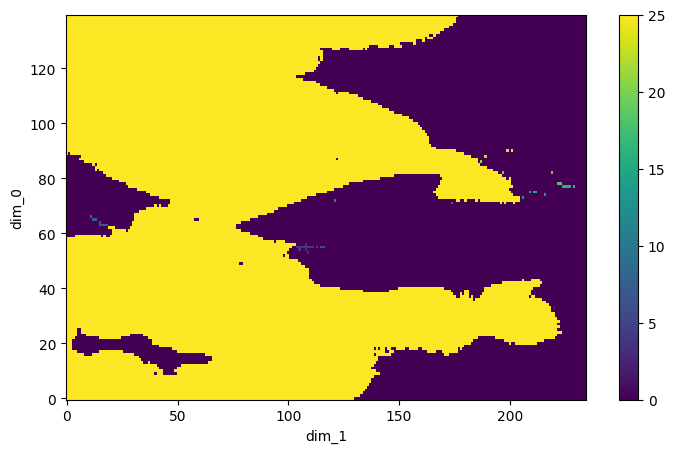

In [4]:
topo.basintmask.plot(size=5, aspect=grid.nx/grid.ny)

The manual mask is not initialized. Initializing it now from the depth raw mask


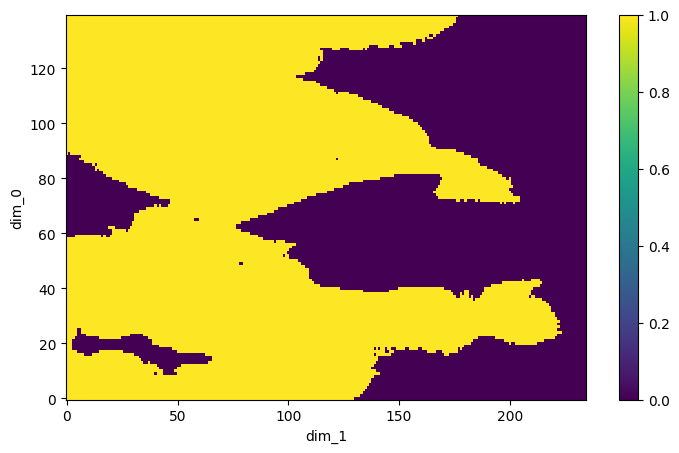

In [5]:
topo.keep_largest_basin()
topo.basintmask.plot(size=5, aspect=grid.nx/grid.ny)

In [6]:
# Optionally, uncomment the below lines to further modify the topography interactively
%matplotlib ipympl
from CrocoDash.topo_editor import TopoEditor
TopoEditor(topo)

TopoEditor(children=(VBox(children=(HTML(value='<h2>Topo Editor</h2>'), VBox(children=(VBox(children=(HTML(val…

In [7]:
topo.write_topo('/glade/work/skygale/crocodile2026/workspace/my-project/my-grid.nc')

PermissionError: [Errno 13] Permission denied: '/glade/work/skygale/crocodile2026/workspace/my-project/my-grid.nc'

## Step 1.3: Vertical Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [ ]:
from CrocoDash.vgrid import VGrid

vgrid = VGrid.hyperbolic(
    nk=20,  # number of vertical levels
    depth=topo.max_depth,
    ratio=50.0  # target ratio of top to bottom layer thicknesses
)

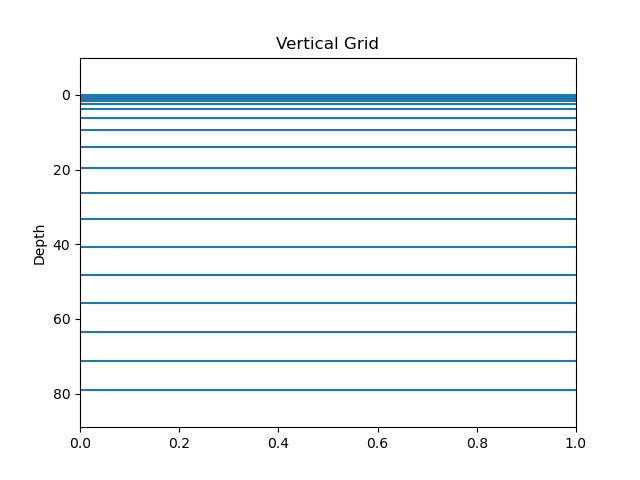

In [ ]:
import matplotlib.pyplot as plt
plt.close()
# Create the plot
for depth in vgrid.zi:
    plt.axhline(y=depth, linestyle='-')  # Horizontal lines

plt.ylim(max(vgrid.zi) + 10, min(vgrid.zi) - 10)  # Invert y-axis so deeper values go down
plt.ylabel("Depth")
plt.title("Vertical Grid")
plt.show()

# SECTION 2: Create the CESM case

After generating the MOM6 domain, the next step is to create a CESM case using CrocoDash. This process is straightforward and involves instantiating the CrocoDash Case object. The Case object requires the following inputs:

 - CESM Source Directory: A local path to a compatible CESM source copy. For the workshop, this is the `CESM/` folder of your CROCODILEworkspace install.
 - Case Name: A unique name for the CESM case. For the workshop, cases go in the `croc_cases/` folder of your CROCODILEworkspace install, in a folder named after the case.
 - Input Directory: The directory where all necessary input files will be written. You don't need to put anything in it: CrocoDash creates it and fills it with the grid, bathymetry and forcing files automatically. For the workshop, it's the `croc_input/` folder of your CROCODILEworkspace install.
 - MOM6 Domain Objects: The horizontal grid, topography, and vertical grid created in the previous section.
 - Project ID: (Optional) A project ID, if required by the machine. For the workshop, use `UCGD0009`.
 - Compset: The set of models to be used in the Case. Standalone Ocean, Ocean-BGC, Ocean-Seaice, Ocean-Wave, etc.

If you installed this notebook with CROCODILEworkspace, these paths and the project ID are already filled in for you in the code below.

## Step 2.1: Specify case name and directories:

Begin by specifying the case name and the necessary directory paths. Ensure the CESM root directory points to your own local copy of CESM. Below is an example setup:

In [ ]:
from pathlib import Path

# CESM case (experiment) name
casename = "merbok_ocn_wav_ice.001"

# CESM source root (Update this path accordingly!)
cesmroot = "/glade/work/geraint/crocodile2026/CESM"

# Place where all your input files go
inputdir = Path("/glade/derecho/scratch/geraint/croc_input") / casename

# CESM case directory
caseroot = Path("/glade/derecho/scratch/geraint/croc_cases") / casename

## Step 2.2: Create the Case

To create the CESM case, instantiate the `Case` object as shown below. This will automatically set up the CESM case based on the provided inputs: The `cesmroot` argument specifies the path to your local CESM source directory.
The `caseroot` argument defines the directory where the case will be created. CrocoDash will handle all necessary namelist modifications and XML changes to align with the MOM6 domain objects generated earlier.
The `job_queue` and `job_wallclock_time` arguments set the PBS queue and the walltime (`hh:mm:ss`) CESM requests when you submit the run; leave them out to use the machine defaults.

📖 [Case documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/2_case_setup.html)

### Compset quick-reference

The `compset` argument controls which model components are active. 

| What you want | Change in `compset=` |
|---|---|
| Ocean only (default) | `compset="CR_JRA"` |
| + Waves (WW3) | `compset="CWR_JRA"` |
| + **Sea ice (CICE6)** | **`compset="GWR_JRA"`** |
| + Biogeochemistry (MARBL) | add `%MARBL-BIO` to the MOM6 component, e.g. `MOM6%REGIONAL%MARBL-BIO` |
| + Data runoff (GLOFAS) | use `CWR_JRA_GLOFAS` |
| + Data runoff (JRA) | use `CWR_JRA` with `DROF%JRA` (see runoff notebook) |

**Note** that in this notebook, we are switching from `"CR_JRA"` to `"GWR_JRA"` to enable WW3 and CICE. 

For a deeper dive into each option:
- **CICE or BGC**: [Case Setup, Sections 3–4](case_setup.ipynb#case-cice)
- **Runoff (GLOFAS / JRA / custom)**: [Configure Forcings, Section 5](configure_forcings.ipynb#forcings-runoff)


In [ ]:
from CrocoDash.case import Case

case = Case(
    cesmroot=cesmroot,
    caseroot=caseroot,
    inputdir=inputdir,
    ocn_grid=grid,
    ocn_vgrid=vgrid,
    ocn_topo=topo,
    project='UCGD0009', # Enter Project ID for PBS Queue
    # job_queue = "tutorial", # PBS queue the run is submitted to
    job_wallclock_time="12:00:00", # hh:mm:ss walltime requested for the run
    override=True,
    machine="derecho",
    compset="GWR_JRA"
)

WARNING [CIME.XML.grids] Schema validity test fails for /glade/work/skygale/crocodile2026/CESM/ccs_config/config_grids_nuopc.xml


Creating case...

Running the create_newcase tool with the following command:

/glade/work/skygale/crocodile2026/CESM/cime/scripts/create_newcase --compset GWR_JRA --res USER_RES --case /glade/derecho/scratch/skygale/croc_cases/merbok_ocn_wav_ice.001 --machine derecho --run-unsupported --handle-preexisting-dirs a --pecount S --project UCGD0009 --non-local 

The create_newcase command was successful.

• Updating case xml variables to include newly generated ocean grid "merbok" with the following properties:
 nx: 235, ny: 140. ocean mesh: /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn/ESMF_mesh_merbok_5800fd.nc.

./xmlchange OCN_GRID=merbok --non-local
./xmlchange OCN_NX=235 --non-local
./xmlchange OCN_NY=140 --non-local
./xmlchange OCN_DOMAIN_MESH=/glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn/ESMF_mesh_merbok_5800fd.nc --non-local
./xmlchange ICE_GRID=merbok --non-local
./xmlchange ICE_NX=235 --non-local
./xmlchange ICE_NY=140 --non-local
./x

# Section 3: Prepare ocean, wave, and sea ice forcing data

We need to cut out our ocean and waves forcing. The package expects an initial condition and one time-dependent segment per non-land boundary. Naming convention is `"east_unprocessed"` for segments and `"ic_unprocessed"` for the initial condition.

In this notebook, we are forcing with the Copernicus Marine "Glorys" reanalysis dataset. There's a function in the `CrocoDash` package, called `configure_forcings`, that generates a bash script to download the correct boundary forcing files for your experiment. First, you will need to create an account with Copernicus, and then call `copernicusmarine login` to set up your login details on your machine. Then you can run the `get_glorys_data.sh` bash script.

## Step 3.1 Configure Initial Conditions and Forcings

📖 [Configure forcings docs](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3a_configure_forcings.html) · [Available datasets](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html)

In [ ]:
./case.configure_forcings(
    date_range=["2022-08-01 00:00:00", "2022-11-01 00:00:00"],
    boundaries=["north","west","south"],
    product_name="GLORYS",
    function_name="get_glorys_data_from_rda",
    ww3_obc_product_name='CESM-WW3-JRA',
    ww3_obc_function_name="get_cesm_ww3_jra_spectra",        
    restore_ice=True,
    cice_product_name="cice_restart",
    cice_function_name="get_cice_restart_subset",
    cice_function_args={
        "restart_path": "/glade/u/home/dbailey/b.e30_alpha09b.B1850C_MTso.ne30_t233_wgx3.360.cice.r.0201-01-01-00000.nc",
        "grid_path": "/glade/campaign/cesm/community/omwg/grids/tx2_3v3_grid.nc",
    },        
)

INFO [CrocoDash.forcing.base] [REQUIRED] Activating StreamYears
INFO [CrocoDash.forcing.base] [SKIP] BGC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIronForcing incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCRiverNutrients incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] Chl missing args: ['chl_processed_filepath']
INFO [CrocoDash.forcing.base] [REQUIRED] Activating CICE
INFO [CrocoDash.forcing.base] [REQUIRED] Activating conditions
INFO [CrocoDash.forcing.base] [SKIP] Runoff incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] tides missing args: ['tpxo_elevation_filepath', 'tpxo_velocity_filepath', 'tidal_constituents']
INFO [CrocoDash.forcing.base] [REQUIRED] Activating WW3
INFO [CrocoDash.forcing.base] Configuring StreamYears


WARNING [CrocoDash.forcing.atm] DROF stream years left at CESM defaults: no active drof


Adding parameter changes to user_nl_datm_streams:

  ! Align CORE_IAF_JRA_1p5_2023 streams with the run dates (CrocoDash: CDEPS defaults to year_align=1)
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_first = 2020
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_last = 2023
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_align = 2020
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:datafiles = /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2020.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2021.220505.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2022.230718.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2023.240531.nc
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_first = 2020
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_last = 2023
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_align = 2020
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:datafiles = /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1

Notice above that we add two new arguments, `"ww3_obc_product_name"` and `"ww3_obc_function_name"` for wave boundary conditions. Additionally, we add four arguments for sea ice. `restore_ice=True` together with `cice_product_name` and `cice_function_name` turns on CICE boundary restoring; you must give all three or none. The `cice_restart` product regrids a global CICE restart (`restart_path` and its grid file `grid_path`) onto our domain with a one-cell border. That single file is both CICE's initial condition and the state the boundary cells are restored toward. 

##  Step 3.3: Process forcing data

In this final step, we call the `process_forcings` method of CrocoDash to cut out and interpolate the initial condition as well as all boundaries. CrocoDash also updates MOM6/WW3 runtime parameters and CESM xml variables accordingly.

In [ ]:
case.process_forcings()

INFO [CrocoDash.forcing.obc] No bathymetry_path given; using full supergrid bounding boxes.
INFO [CrocoDash.forcing.obc] GET [north]: 2022-08-01 → 2022-11-01
INFO [CrocoDash.forcing.obc] GET [west]: 2022-08-01 → 2022-11-01
INFO [CrocoDash.forcing.obc] GET [south]: 2022-08-01 → 2022-11-01
INFO [CrocoDash.forcing.obc] REGRID [north]: None-day slices
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Spun up new proc
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Chunk start - end date: [2022-08-01] - [2022-11-01]
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Selecting raw files
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Performing regrid
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Regridding done for /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/extract_forcings/ww3/regridded_data/forcing_obc_segment_001_2022-08-01_2022-11-01.nc
INFO [CrocoDash.forcing.obc] REGRID [west]: None-day slices
INFO [CrocoDash.forcing.obc] PROC

WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array u, assuming it's in the correct units
WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array v, assuming it's in the correct units
WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array temp, assuming it's in the correct units


No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping
Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

WARNING [regional_mom6.validate] eta_t does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable eta_t does not have 4 dimensions
WARNING [regional_mom6.validate] temp does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable temp does not have 4 dimensions
WARNING [regional_mom6.validate] salt does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable salt does not have 4 dimensions
WARNING [regional_mom6.validate] u does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable u does not have 4 dimensions
WARNING [regional_mom6.validate] v does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable v does not have 4 dimensions


INFO [CrocoDash.forcing.mom6] Start mom6_forge fill...
INFO [CrocoDash.forcing.mom6] ...end mom6_forge fill.
INFO [CrocoDash.forcing.ic] Successfully retrieved GLORYS initial condition data located in /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn directory.


...

INFO [CrocoDash.forcing.obc] PROC [3] - REGRID [south]: Regridding done for /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/extract_forcings/regridded_data/forcing_obc_segment_003_2022-10-30_2022-11-01.nc


WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array u, assuming it's in the correct units
WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array v, assuming it's in the correct units
WARNING [regional_mom6.validate] temp_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] salt_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] u_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] v_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] eta_segment_003 does not have a coordinates attribute


INFO [CrocoDash.forcing.obc] PROC [2] - REGRID [south]: Regridding done for /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/extract_forcings/regridded_data/forcing_obc_segment_003_2022-09-30_2022-10-29.nc


WARNING [regional_mom6.validate] temp_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] temp_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] salt_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] u_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] salt_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] v_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] u_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] eta_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] v_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] eta_segment_003 does not have a coordinates attribute


INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [south]: Regridding done for /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/extract_forcings/regridded_data/forcing_obc_segment_003_2022-08-01_2022-08-30.nc
INFO [CrocoDash.forcing.obc] PROC [1] - REGRID [south]: Regridding done for /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/extract_forcings/regridded_data/forcing_obc_segment_003_2022-08-31_2022-09-29.nc
INFO [CrocoDash.forcing.obc] MERGE [north]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn/forcing_obc_segment_001.nc
INFO [CrocoDash.forcing.obc] MERGE [west]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn/forcing_obc_segment_002.nc
INFO [CrocoDash.forcing.obc] MERGE [south]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/derecho/scratch/skygale/croc_input/merbok_ocn_wav_ice.001/ocn/forci

In [ ]:
./

In [ ]:
print("You can now build and run your case at", caseroot)

You can now build and run your case at /glade/derecho/scratch/skygale/croc_cases/merbok_ocn_wav_ice.001


# Section 4: Build and run the case

After completing the previous steps, you are ready to build and run your CESM case. Begin by navigating to the case root directory specified during the case creation. Before proceeding, review the `user_nl_mom` file located in the case directory. This file contains MOM6 parameter settings that were automatically generated by CrocoDash. Carefully examine these parameters and make any necessary adjustments to fine-tune the model for your specific requirements. While CrocoDash aims to provide a solid starting point, further tuning and adjustments are typically necessary to improve the model for your use case.

Once you have reviewed and modified the parameters as needed, you can build and execute the case using the following commands. CESM cases must be built and submitted on the machine you passed as `machine` when creating the `Case`. For the workshop, that's **Derecho** (not Casper), so the commands start by logging in to Derecho and going to the case directory:
```
ssh derecho
cd /glade/work/skygale/crocodile2026/croc_cases/bering_ocn_wav_ice.001
qcmd -A UCGD0009 -- ./case.build
./case.submit
```

# Where to go from here?

This tutorial covered the basics of CrocoDash. Extend it with features or jump into a real-world example:

## Add more components
- [Case Setup: Coupling (CICE / BGC)](case_setup.ipynb#case-cice): sea ice or biogeochemistry
- [Configure Forcings: Tides](configure_forcings.ipynb#forcings-tides)
- [Configure Forcings: Chlorophyll](configure_forcings.ipynb#forcings-chlorophyll)
- [Configure Forcings: Runoff](configure_forcings.ipynb#forcings-runoff)

## Try a different domain
- [Grids: Polar Projections](grids.ipynb#grids-polar): Arctic & Antarctic domains
- [Grids: Pre-Generated or Subset](grids.ipynb#grids-pregenerated): pre-generated supergrid or global subset

## Real-world examples
- [NWA12 (North-West Atlantic 1/12°)](use_cases/three_boundary.ipynb)
- [Antarctic CICE coupled run](use_cases/mom6_cice_antarctica.ipynb)
- [Low-resolution domain for data assimilation](use_cases/three_boundary_from_t232.ipynb)

## Explore model output
- [mom6-tools Diagnostics](../mom6_tools.md)
- [CARIB12 EKE Analysis](../model2obs/CARIB12_EKE_TS.ipynb)
- [Model–Observation Comparison](../model2obs/model-obs_comparison.md)

## Full documentation

The complete CrocoDash reference is at **[https://crocodile-cesm.github.io/CrocoDash/latest/](https://crocodile-cesm.github.io/CrocoDash/latest/)**:

- [Installation](https://crocodile-cesm.github.io/CrocoDash/latest/installation.html)
- [Grids (horizontal, topography, vertical)](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)
- [Available datasets](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html)
- [Forcing extraction](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3b_process_forcings.html)
- [Forcing configurations](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3a_configure_forcings.html)
- [Bundling & forking cases](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/shareable.html)
- [API reference](https://crocodile-cesm.github.io/CrocoDash/latest/api-docs/modules.html)